# Where does the K = 10 gain actually live? -- the 6-click fill-geometry run, sliced by domain

**What this is.** `fill_geometry_precision_at_10_49roi_6seed.ipynb` established one thing at K = 10: on
`tm_score`, production's default ranking axis, flattening the seed template's surround is worth
**+1.80 points** of precision@10 (`hem_rect_fill - default_51`, bootstrap CI [+0.48, +3.20], Holm 0.0436),
and the three keep-regions that do the flattening are indistinguishable from one another. On the opt-in
`chromatin_od` axis nothing separates.

That is a **pooled** number over 49 ROIs. This notebook asks where inside those 49 ROIs it comes from,
and answers with pictures. It **re-runs no pipeline**: every number is read from the audited CSVs of that
run, and the domain slices are built from `delta_per_roi.csv` and `per_run.csv` alone.

**The 49 ROIs are 7 domains x 7 ROIs, exactly balanced** -- 4 canine tumour types and 3 human ones, 2 ROIs
each from the `original_14` subset and 5 from `testing_35`.

## What a domain slice can and cannot resolve

This is a **descriptive decomposition of an established pooled result, not seven new experiments.** The
distinction is not a formality -- at n = 7 ROIs per domain it is arithmetic:

- A ROI's delta is its TP@10 summed over 6 clicks, so a domain's precision moves in steps of `1/420`.
- The exact sign-flip p cannot fall below `2 ** (1 - n_nonzero)`, and `n_nonzero` is at most 7, so the
  smallest p any domain could ever produce is **0.0156**.
- Correcting across 7 domains multiplies that floor by 7: **0.109**. It is larger than 0.05.

**So no domain can reach corrected significance at any effect size whatsoever.** Cell 2 prints this
arithmetic rather than asserting it. Every per-domain CI below is therefore shown as a *spread*, not a
test, and no per-domain verdict is issued anywhere in this notebook. A previous domain slice of an earlier
run (`hem_rect_fill_vs_default_chromatin_od_by_domain.ipynb`) reached the same conclusion, and its one
promising domain later shrank toward zero when its n was tripled -- which is the precedent this notebook
is written against.

## What is shown

Every figure is at **K = 10 only** (the run's only tested budget), both ranking axes, and the primary
contrast `hem_rect_fill - default_51` unless stated.

1. **The decomposition** -- each domain's delta with its ROI-level spread underneath it.
2. **The levels** -- absolute precision@10 per domain for all four arms, because a delta means nothing
   without knowing whether the domain sits at 32% or 70%.
3. **The fragility** -- what each domain number does when read at 3 clicks instead of 6, when its largest
   ROI is removed, and how far its p-value floor sits from significance.
4. **The pattern the domains make** -- the domain ordering tracks how much of the 51 px window each arm
   actually overwrites, and that gradient is present on `tm_score` and absent on `chromatin_od`.

## Correctness gate

The domain slices have no recorded reference, so the local statistics code is validated first: Cell 2
recomputes the parent run's **all-49** `delta_stats.csv` with the same `pair_stats` used on every domain
and asserts it bit-exact, on all 10 rows. Only then is that code pointed at a domain.

In [1]:
import math
from fractions import Fraction

import numpy as np
import pandas as pd
from scipy import stats as sps
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

pd.set_option('display.width', 250)
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 400)

SRC = '../results/precision_at_k_49roi_6seed_fillgeom_postD11'
OUT = {
    'domain_stats': f'{SRC}_by_domain_delta_stats.csv',
    'domain_precision': f'{SRC}_by_domain_precision.csv',
}
FIG = {
    'decomposition': 'fillgeom6_domain_decomposition.png',
    'levels': 'fillgeom6_domain_levels.png',
    'fragility': 'fillgeom6_domain_fragility.png',
    'dose': 'fillgeom6_domain_dose.png',
}

TEST_K = 10                       # the parent run's only tested budget; K = 20 and 30 are descriptive there and unused here
N_CLICKS = 6
N_ROIS = 49
N_PER_DOMAIN = 7
WINDOW_PX = 51 ** 2               # the 51 x 51 template window every arm cuts
BASELINE = 'default_51'
HEADLINE = f'hem_rect_fill - {BASELINE}'
PRIMARY = (f'hem_rect_fill - {BASELINE}', f'hem_rect_fill_1um - {BASELINE}', f'hem_mask_fill_1um - {BASELINE}')
ARMS = (BASELINE, 'hem_rect_fill', 'hem_rect_fill_1um', 'hem_mask_fill_1um')
AXES = ('tm_score', 'chromatin_od')
AXIS_NOTE = {'tm_score': "tm_score  —  production's default ranking axis", 'chromatin_od': 'chromatin_od  —  the opt-in second axis'}
N_BOOT = 10_000
BOOT_SEED = 20260917              # the parent run's seed, reused so Cell 2's all-49 reproduction is bit-exact

# validated reference palette (dataviz skill, references/palette.md): categorical slots 1-2, diverging blue<->red, neutral gray, chrome
BLUE, ORANGE, RED, GRAY = '#2a78d6', '#eb6834', '#e34948', '#898781'
INK, MUTED, GRID, SURFACE = '#0b0b0b', '#52514e', '#e1e0d9', '#fcfcfb'
ARM_COLOR = {BASELINE: INK, 'hem_rect_fill': BLUE, 'hem_rect_fill_1um': ORANGE, 'hem_mask_fill_1um': GRAY}
ARM_LABEL = {BASELINE: 'default_51 (the whole window)', 'hem_rect_fill': 'hem_rect_fill (Otsu rectangle)', 'hem_rect_fill_1um': 'hem_rect_fill_1um (+1 um)', 'hem_mask_fill_1um': 'hem_mask_fill_1um (component +1 um)'}
# short axis labels for the figures; the mapping is printed so no name is hidden behind an abbreviation
SHORT = {'canine cutaneous mast cell tumor': 'canine mast cell', 'canine lung cancer': 'canine lung', 'canine lymphosarcoma': 'canine lymphosarcoma',
         'canine soft tissue sarcoma': 'canine soft tissue', 'human breast cancer': 'human breast', 'human melanoma': 'human melanoma',
         'human neuroendocrine tumor': 'human neuroendocrine'}
POOLED_LABEL = 'ALL 49 ROIs (pooled)'

print(f'source run: {SRC}_*.csv  (no pipeline is re-run here)')
print(f'K = {TEST_K} only; {N_CLICKS} clicks per ROI; axes {AXES}')
print(f'headline contrast: {HEADLINE}')
print('outputs:', *OUT.values(), *FIG.values(), sep='\n  ')

source run: ../results/precision_at_k_49roi_6seed_fillgeom_postD11_*.csv  (no pipeline is re-run here)
K = 10 only; 6 clicks per ROI; axes ('tm_score', 'chromatin_od')
headline contrast: hem_rect_fill - default_51
outputs:
  ../results/precision_at_k_49roi_6seed_fillgeom_postD11_by_domain_delta_stats.csv
  ../results/precision_at_k_49roi_6seed_fillgeom_postD11_by_domain_precision.csv
  fillgeom6_domain_decomposition.png
  fillgeom6_domain_levels.png
  fillgeom6_domain_fragility.png
  fillgeom6_domain_dose.png


In [2]:
PER_RUN = pd.read_csv(f'{SRC}_per_run.csv', float_precision='round_trip')
DELTA = pd.read_csv(f'{SRC}_delta_per_roi.csv', float_precision='round_trip')
STATS_REC = pd.read_csv(f'{SRC}_delta_stats.csv', float_precision='round_trip')
CLICKS = pd.read_csv(f'{SRC}_clicks.csv', float_precision='round_trip')

ROI_ORDER = PER_RUN['file_name'].drop_duplicates().tolist()   # the parent run's ROI row order; BOOT_SEED only reproduces its CIs in this order
ROI_META = PER_RUN.groupby('file_name', sort=False)[['subset', 'domain']].first().loc[ROI_ORDER]
DOMAINS = sorted(ROI_META['domain'].unique())

assert len(PER_RUN) == N_ROIS * N_CLICKS * len(ARMS) * len(AXES), f'{len(PER_RUN)} per_run rows'
assert len(ROI_ORDER) == N_ROIS and len(DOMAINS) == 7, f'{len(ROI_ORDER)} ROIs in {len(DOMAINS)} domains'
assert (ROI_META.groupby('domain').size() == N_PER_DOMAIN).all(), 'the 7 domains are not balanced at 7 ROIs each'
assert set(SHORT) == set(DOMAINS), 'the short-label map does not cover exactly the domains present'
assert (DELTA['K'] == TEST_K).all() and len(DELTA) == len(AXES) * 5 * N_ROIS, 'delta_per_roi is not 2 axes x 5 pairs x 49 ROIs at one K'


def sign_flip_null_counts(abs_deltas):
    """
        Exact null distribution of sum(+/-|d_i|) by convolution over integer offsets.

        abs_deltas (array-like): nonzero absolute integer deltas, one per ROI.

        Returns np.ndarray: int64 counts of each sum -T..T (index = sum + T, T = sum |d_i|), totalling 2 ** n.
    """
    d = [int(v) for v in abs_deltas]
    assert all(v > 0 for v in d) and len(d) <= 62, 'nonzero integer deltas only, and 2 ** n must fit int64'
    total = sum(d)
    counts = np.zeros(2 * total + 1, dtype=np.int64)
    counts[total] = 1
    for v in d:
        shifted = np.zeros_like(counts)
        shifted[v:] += counts[:len(counts) - v]
        shifted[:len(counts) - v] += counts[v:]
        counts = shifted
    return counts


def exact_sign_flip_p(deltas):
    """
        Two-sided exact sign-flip p on integer per-ROI deltas, by dynamic-programming convolution.

        deltas (array-like): one integer delta per ROI; zeros carry no sign.

        Returns tuple[float, int]: the p-value and the number of nonzero deltas.
    """
    d = np.asarray(deltas)
    assert np.all(d == np.round(d)), 'the convolution needs integer deltas'
    d = d.astype(np.int64)
    nz = np.abs(d[d != 0])
    if len(nz) == 0:
        return 1.0, 0
    counts = sign_flip_null_counts(nz)
    total = int(nz.sum())
    observed = abs(int(d.sum()))
    sums = np.arange(-total, total + 1)
    return float(Fraction(int(counts[np.abs(sums) >= observed].sum()), 2 ** len(nz))), len(nz)


def holm_adjust(pvalues):
    """
        Holm step-down adjusted p-values, valid under any dependence between the tests.

        pvalues (array-like): raw p-values of one family of tests.

        Returns np.ndarray: adjusted p-values, in the input order.
    """
    p = np.asarray(pvalues, dtype=float)
    order = np.argsort(p, kind='stable')
    adjusted = np.maximum.accumulate((len(p) - np.arange(len(p))) * p[order]).clip(max=1.0)
    out = np.empty_like(adjusted)
    out[order] = adjusted
    return out


def pair_stats(deltas, boot_idx, n_clicks=N_CLICKS, k=TEST_K):
    """
        Pooled delta, cluster-bootstrap CI, t interval and exact sign-flip p for one set of per-ROI deltas.

        deltas (array-like): one integer TP delta per ROI, in a fixed ROI order.
        boot_idx (np.ndarray): (n_boot, n_roi) resampled ROI indices.
        n_clicks (int): clicks summed into each ROI's delta.
        k (int): the budget K the deltas were counted at.

        Returns dict: one statistics row.
    """
    d = np.asarray(deltas, dtype=np.int64)
    n_roi = len(d)
    denominator = n_clicks * n_roi * k
    pooled = d.sum() / denominator
    sums = d[boot_idx].sum(axis=1)                 # exact integer resample sums: a resample summing to 0 is exactly 0, not float noise
    ci_low, ci_high = np.percentile(sums / denominator, [2.5, 97.5])
    exact_p, n_nonzero = exact_sign_flip_p(d)
    x = d / (n_clicks * k)
    half = sps.t.ppf(0.975, n_roi - 1) * x.std(ddof=1) / math.sqrt(n_roi)
    wins, losses, ties = int((d > 0).sum()), int((d < 0).sum()), int((d == 0).sum())
    return dict(n_roi=n_roi, pooled_delta_precision=pooled, wins=wins, losses=losses, ties=ties, n_nonzero=n_nonzero,
                exact_p=exact_p, min_attainable_p=2.0 ** (1 - n_nonzero) if n_nonzero else 1.0,
                ci_low=float(ci_low), ci_high=float(ci_high), t_ci_low=float(x.mean() - half), t_ci_high=float(x.mean() + half),
                ci_excludes_0=bool(ci_low > 0 or ci_high < 0))


# --- gate: the local pair_stats must reproduce the parent run's all-49 delta_stats.csv bit for bit, before it touches a domain slice
BOOT_IDX_49 = np.random.default_rng([BOOT_SEED, 0]).integers(N_ROIS, size=(N_BOOT, N_ROIS))
checked = 0
for row in STATS_REC.itertuples():
    d = DELTA.loc[(DELTA['rank_key'] == row.rank_key) & (DELTA['pair'] == row.pair)].set_index('file_name').loc[ROI_ORDER, 'delta_tp_sum'].to_numpy()
    mine = pair_stats(d, BOOT_IDX_49)
    for col in ('pooled_delta_precision', 'ci_low', 'ci_high', 't_ci_low', 't_ci_high', 'exact_p', 'min_attainable_p'):
        assert mine[col] == getattr(row, col), f'{row.rank_key} {row.pair}: {col} {mine[col]!r} != recorded {getattr(row, col)!r}'
    for col in ('wins', 'losses', 'ties', 'n_nonzero'):
        assert mine[col] == int(getattr(row, col)), f'{row.rank_key} {row.pair}: {col} differs from the recorded run'
    checked += 1
assert checked == 10, f'{checked} recorded delta_stats rows reproduced, expected 10'
print(f'gate passed: pair_stats reproduces all {checked} recorded all-49 delta_stats rows bit for bit (pooled delta, both CIs, exact p, W/L/T)')

# --- the resolution floor, computed rather than asserted
floor_one = 2.0 ** (1 - N_PER_DOMAIN)
floor_holm = floor_one * len(DOMAINS)
print(f'\nresolution at n = {N_PER_DOMAIN} ROIs per domain:')
print(f'  precision step per domain            1/{N_CLICKS * N_PER_DOMAIN * TEST_K} = {100 / (N_CLICKS * N_PER_DOMAIN * TEST_K):.3f} points')
print(f'  smallest exact sign-flip p possible  2 ** (1 - {N_PER_DOMAIN}) = {floor_one:.4f}')
print(f'  x {len(DOMAINS)} domains (Holm floor)          {floor_holm:.4f}   -> {"ABOVE" if floor_holm > 0.05 else "below"} 0.05')
print(f'  => no domain can reach corrected significance at any effect size. Every per-domain CI below is a spread, not a test.')

gate passed: pair_stats reproduces all 10 recorded all-49 delta_stats rows bit for bit (pooled delta, both CIs, exact p, W/L/T)

resolution at n = 7 ROIs per domain:
  precision step per domain            1/420 = 0.238 points
  smallest exact sign-flip p possible  2 ** (1 - 7) = 0.0156
  x 7 domains (Holm floor)          0.1094   -> ABOVE 0.05
  => no domain can reach corrected significance at any effect size. Every per-domain CI below is a spread, not a test.


In [3]:
# One statistics row per (axis, pair, domain), plus the all-49 pooled row for reference. Each domain resamples its
# own 7 ROIs, with a per-domain bootstrap stream so one domain's CI does not depend on the others' ROI counts.
DOMAIN_ROWS = []
for axis in AXES:
    for pair in PRIMARY:
        sub = DELTA[(DELTA['rank_key'] == axis) & (DELTA['pair'] == pair)].set_index('file_name').loc[ROI_ORDER]
        DOMAIN_ROWS.append(dict(rank_key=axis, pair=pair, domain=POOLED_LABEL, scope='pooled',
                                **pair_stats(sub['delta_tp_sum'].to_numpy(), BOOT_IDX_49),
                                delta_3click=sub['delta_tp_recorded_seeds'].sum() / (3 * N_ROIS * TEST_K), loo_file='', loo_delta_tp=np.nan, loo_delta=np.nan))
        for di, dom in enumerate(DOMAINS):
            g = sub[sub['domain'] == dom]
            d = g['delta_tp_sum'].to_numpy()
            boot_idx = np.random.default_rng([BOOT_SEED, 1, di]).integers(N_PER_DOMAIN, size=(N_BOOT, N_PER_DOMAIN))
            loo_i = g['delta_tp_sum'].abs().idxmax()                      # the ROI whose delta is largest in magnitude, this domain's single point of failure
            rest = d.sum() - int(g.loc[loo_i, 'delta_tp_sum'])
            DOMAIN_ROWS.append(dict(rank_key=axis, pair=pair, domain=dom, scope='domain',
                                    **pair_stats(d, boot_idx),
                                    delta_3click=g['delta_tp_recorded_seeds'].sum() / (3 * N_PER_DOMAIN * TEST_K),
                                    loo_file=loo_i, loo_delta_tp=int(g.loc[loo_i, 'delta_tp_sum']), loo_delta=rest / (N_CLICKS * (N_PER_DOMAIN - 1) * TEST_K)))
DOMAIN_STATS = pd.DataFrame(DOMAIN_ROWS)

# Holm across the 7 domains, within each (axis, pair) -- reported only to show that nothing reaches it
DOMAIN_STATS['holm_p'] = np.nan
is_dom = DOMAIN_STATS['scope'] == 'domain'
for (axis, pair), g in DOMAIN_STATS[is_dom].groupby(['rank_key', 'pair']):
    DOMAIN_STATS.loc[g.index, 'holm_p'] = holm_adjust(g['exact_p'].to_numpy())
DOMAIN_STATS['holm_adjusted_floor'] = DOMAIN_STATS['min_attainable_p'] * np.where(is_dom, len(DOMAINS), 3)
DOMAIN_STATS['bounds_nothing'] = DOMAIN_STATS['holm_adjusted_floor'] > 0.05
DOMAIN_STATS.to_csv(OUT['domain_stats'], index=False)
assert len(DOMAIN_STATS) == len(AXES) * len(PRIMARY) * (len(DOMAINS) + 1), 'domain_stats is not 2 axes x 3 pairs x (7 domains + pooled)'
print(f"-> {OUT['domain_stats']}  ({len(DOMAIN_STATS)} rows = {len(AXES)} axes x {len(PRIMARY)} pairs x ({len(DOMAINS)} domains + pooled))")

# figure order, fixed everywhere below: by the headline tm_score delta, ascending, so the largest gain sits at the top
ORDER = (DOMAIN_STATS[(DOMAIN_STATS['rank_key'] == 'tm_score') & (DOMAIN_STATS['pair'] == HEADLINE) & is_dom]
         .sort_values(['pooled_delta_precision', 'domain'], ascending=[True, False])['domain'].tolist())

show = DOMAIN_STATS[(DOMAIN_STATS['pair'] == HEADLINE)].copy()
show['delta_pts'] = (100 * show['pooled_delta_precision']).round(2)
show['boot_ci95'] = [f'[{100 * lo:+.2f}, {100 * hi:+.2f}]' for lo, hi in zip(show['ci_low'], show['ci_high'])]
show['wlt'] = show['wins'].astype(str) + '/' + show['losses'].astype(str) + '/' + show['ties'].astype(str)
for axis in AXES:
    print(f'\n=== {HEADLINE}, K = {TEST_K}, rank_key = {axis} ===')
    s = show[show['rank_key'] == axis].set_index('domain').loc[[POOLED_LABEL] + ORDER[::-1]]
    print(s[['n_roi', 'delta_pts', 'boot_ci95', 'wlt', 'n_nonzero', 'exact_p', 'min_attainable_p', 'holm_p', 'holm_adjusted_floor', 'bounds_nothing']].to_string(float_format=lambda v: f'{v:.4g}'))
for axis in AXES:
    v = 100 * DOMAIN_STATS.loc[(DOMAIN_STATS['rank_key'] == axis) & (DOMAIN_STATS['pair'] == HEADLINE) & is_dom, 'pooled_delta_precision']
    print(f'\n{axis}: the 7 domain deltas span {v.max() - v.min():.2f} points, from {v.min():+.2f} to {v.max():+.2f}')
print(f'\nshort labels used in the figures: ' + '; '.join(f'{k} -> {v}' for k, v in SHORT.items()))

-> ../results/precision_at_k_49roi_6seed_fillgeom_postD11_by_domain_delta_stats.csv  (48 rows = 2 axes x 3 pairs x (7 domains + pooled))

=== hem_rect_fill - default_51, K = 10, rank_key = tm_score ===
                                  n_roi  delta_pts        boot_ci95      wlt  n_nonzero  exact_p  min_attainable_p  holm_p  holm_adjusted_floor  bounds_nothing
domain                                                                                                                                                         
ALL 49 ROIs (pooled)                 49        1.8   [+0.48, +3.20]  24/17/8         41  0.01453         9.095e-13     NaN            2.728e-12           False
canine lymphosarcoma                  7       6.43  [+1.67, +11.43]    5/1/1          6  0.09375           0.03125  0.5625               0.2188            True
canine lung cancer                    7       4.76   [+2.14, +7.38]    5/0/2          5   0.0625            0.0625  0.4375               0.4375            Tru

In [4]:
# Absolute precision@10 per domain per arm -- the level each delta sits on top of.
DOMAIN_PREC = PER_RUN.groupby(['rank_key', 'domain', 'condition'], sort=False).agg(n_roi=('file_name', 'nunique'), tp=(f'tp_at_{TEST_K}', 'sum')).reset_index()
assert (DOMAIN_PREC['n_roi'] == N_PER_DOMAIN).all(), 'a domain does not have 7 ROIs in per_run'
DOMAIN_PREC['precision'] = DOMAIN_PREC['tp'] / (N_CLICKS * N_PER_DOMAIN * TEST_K)

POOLED_PREC = PER_RUN.groupby(['rank_key', 'condition'], sort=False).agg(n_roi=('file_name', 'nunique'), tp=(f'tp_at_{TEST_K}', 'sum')).reset_index()
POOLED_PREC['domain'] = POOLED_LABEL
POOLED_PREC['precision'] = POOLED_PREC['tp'] / (N_CLICKS * N_ROIS * TEST_K)
PREC = pd.concat([DOMAIN_PREC, POOLED_PREC], ignore_index=True)
PREC.to_csv(OUT['domain_precision'], index=False)

# the pooled rows must equal the parent notebook's published table, or the slice is reading a different file
published = {('tm_score', 'default_51'): 0.5085, ('tm_score', 'hem_rect_fill'): 0.5265, ('tm_score', 'hem_rect_fill_1um'): 0.5248, ('tm_score', 'hem_mask_fill_1um'): 0.5252,
             ('chromatin_od', 'default_51'): 0.5667, ('chromatin_od', 'hem_rect_fill'): 0.5680, ('chromatin_od', 'hem_rect_fill_1um'): 0.5718, ('chromatin_od', 'hem_mask_fill_1um'): 0.5697}
for (axis, arm), value in published.items():
    got = POOLED_PREC.loc[(POOLED_PREC['rank_key'] == axis) & (POOLED_PREC['condition'] == arm), 'precision'].iat[0]
    assert round(got, 4) == value, f'{axis} {arm}: pooled precision {got:.4f} != the parent notebook\'s published {value}'
print(f"-> {OUT['domain_precision']}  ({len(PREC)} rows); pooled precision matches the parent notebook's published table on all 8 (axis, arm) cells")

for axis in AXES:
    print(f'\nprecision@{TEST_K} (%), rank_key = {axis}:')
    t = PREC[PREC['rank_key'] == axis].pivot(index='domain', columns='condition', values='precision').loc[[POOLED_LABEL] + ORDER[::-1], list(ARMS)] * 100
    t['gain (rect - default)'] = t['hem_rect_fill'] - t['default_51']
    print(t.round(2).to_string())
    base, fills = t[BASELINE].drop(POOLED_LABEL), t.drop(index=POOLED_LABEL)[list(ARMS[1:])]
    print(f'  baseline precision spans {base.max() - base.min():.2f} points across domains ({base.min():.2f} in {base.idxmin()} to {base.max():.2f} in {base.idxmax()}); '
          f'the 3 fill arms sit within {(fills.max(axis=1) - fills.min(axis=1)).max():.2f} points of each other in every domain')

-> ../results/precision_at_k_49roi_6seed_fillgeom_postD11_by_domain_precision.csv  (64 rows); pooled precision matches the parent notebook's published table on all 8 (axis, arm) cells

precision@10 (%), rank_key = tm_score:
condition                         default_51  hem_rect_fill  hem_rect_fill_1um  hem_mask_fill_1um  gain (rect - default)
domain                                                                                                                  
ALL 49 ROIs (pooled)                   50.85          52.65              52.48              52.52                   1.80
canine lymphosarcoma                   54.52          60.95              61.67              62.38                   6.43
canine lung cancer                     32.14          36.90              35.95              36.43                   4.76
canine cutaneous mast cell tumor       61.19          63.81              62.62              62.38                   2.62
canine soft tissue sarcoma             55.00      

## Figure 1 -- the decomposition

Two rows, because a domain mean and the ROIs under it are different things and get confused when drawn
together. **Top:** each domain's pooled delta with its 95% cluster-bootstrap CI over its own 7 ROIs.
**Bottom:** the 7 ROI deltas that produce it, one dot each. Both rows share an x-axis *within* the row and
across the two ranking axes, so the `chromatin_od` column being flat is the finding, not a scaling choice.

The CIs in the top row are **spreads, not tests** -- Cell 2 printed why none of them could be one.

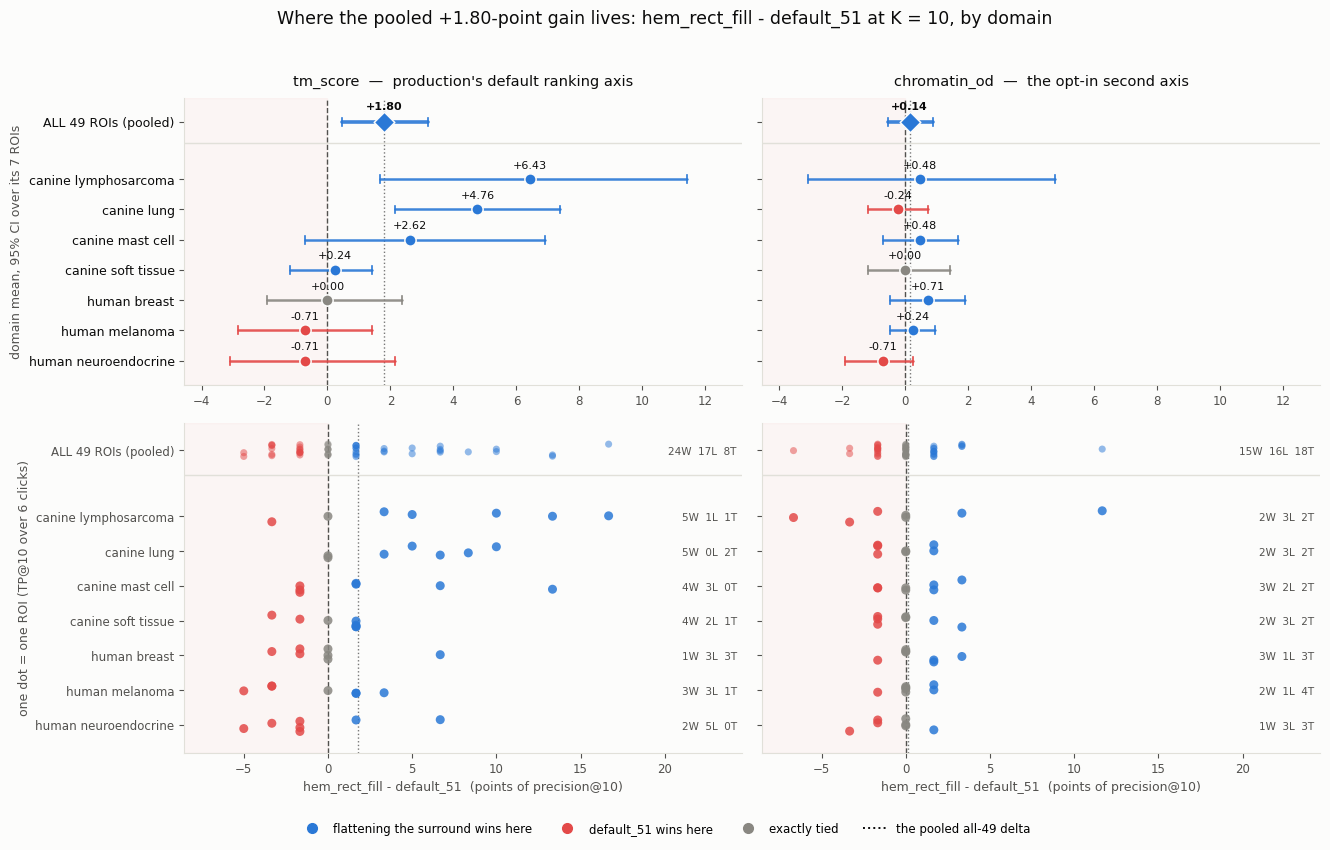

-> fillgeom6_domain_decomposition.png


In [5]:
def recessive(ax):
    """
        Push an axes' frame and grid behind the data, the house style for every panel here.

        ax (matplotlib.axes.Axes): the axes to restyle.

        Returns None.
    """
    ax.set_facecolor(SURFACE)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=8.5)


YPOS = {dom: float(i) for i, dom in enumerate(ORDER)}
YPOS[POOLED_LABEL] = len(ORDER) + 0.9                      # the pooled row sits above a divider, off the domain ladder
YTICKS = [YPOS[d] for d in ORDER] + [YPOS[POOLED_LABEL]]
YLABELS = [SHORT[d] for d in ORDER] + [POOLED_LABEL]
DIVIDER = len(ORDER) - 0.5 + 0.7
PTS = 100 / (N_CLICKS * TEST_K)                            # one TP on one ROI, in points of that ROI's precision

fig, axes = plt.subplots(2, 2, figsize=(13.4, 8.2), sharey=True, sharex='row', facecolor=SURFACE, gridspec_kw={'height_ratios': [1, 1.15]})
jitter_rng = np.random.default_rng(7)

for col, axis in enumerate(AXES):
    top, bottom = axes[0, col], axes[1, col]
    stats = DOMAIN_STATS[(DOMAIN_STATS['rank_key'] == axis) & (DOMAIN_STATS['pair'] == HEADLINE)].set_index('domain')
    pooled_pts = 100 * stats.loc[POOLED_LABEL, 'pooled_delta_precision']

    for ax in (top, bottom):
        recessive(ax)
        ax.axvspan(-1e3, 0, color=RED, alpha=0.035, zorder=0)
        ax.axvline(0, color=MUTED, linewidth=1, linestyle='--', zorder=1)
        ax.axvline(pooled_pts, color=INK, linewidth=1, linestyle=':', alpha=0.55, zorder=1)
        ax.axhline(DIVIDER, color=GRID, linewidth=1, zorder=1)

    # top -- the domain mean and its spread
    for dom in ORDER + [POOLED_LABEL]:
        row, y = stats.loc[dom], YPOS[dom]
        v, lo, hi = 100 * row['pooled_delta_precision'], 100 * row['ci_low'], 100 * row['ci_high']
        is_pooled = dom == POOLED_LABEL
        color = BLUE if v > 0 else RED if v < 0 else GRAY
        top.plot([lo, hi], [y, y], color=color, linewidth=2.6 if is_pooled else 1.8, alpha=0.9, solid_capstyle='round', zorder=3)
        top.plot([lo, lo, np.nan, hi, hi], [y - 0.13, y + 0.13, np.nan, y - 0.13, y + 0.13], color=color, linewidth=1.2, zorder=3)
        top.scatter([v], [y], s=110 if is_pooled else 66, marker='D' if is_pooled else 'o', color=color, edgecolors=SURFACE, linewidths=1.1, zorder=4)
        top.annotate(f'{v:+.2f}', (v, y), xytext=(0, 9 if is_pooled else 8), textcoords='offset points', ha='center', fontsize=8, color=INK, fontweight='bold' if is_pooled else 'normal')

    # bottom -- every ROI behind those means
    for dom in ORDER + [POOLED_LABEL]:
        y = YPOS[dom]
        sub = DELTA[(DELTA['rank_key'] == axis) & (DELTA['pair'] == HEADLINE)]
        vals = (sub if dom == POOLED_LABEL else sub[sub['domain'] == dom])['delta_tp_sum'].to_numpy() * PTS
        offs = jitter_rng.uniform(-0.19, 0.19, size=len(vals))
        colors = [BLUE if v > 0 else RED if v < 0 else GRAY for v in vals]
        bottom.scatter(vals, y + offs, s=26 if dom == POOLED_LABEL else 42, c=colors, alpha=0.5 if dom == POOLED_LABEL else 0.85, edgecolors='none', zorder=3)
        row = stats.loc[dom]
        bottom.annotate(f"{int(row['wins'])}W  {int(row['losses'])}L  {int(row['ties'])}T", (1.0, y), xycoords=('axes fraction', 'data'),
                        xytext=(-4, -3), textcoords='offset points', ha='right', fontsize=7.5, color=MUTED)

    top.set_title(AXIS_NOTE[axis], fontsize=10.5, color=INK, pad=9)
    bottom.set_xlabel(f'{HEADLINE}  (points of precision@{TEST_K})', fontsize=9, color=MUTED)

axes[0, 0].set_ylabel('domain mean, 95% CI over its 7 ROIs', fontsize=9, color=MUTED)
axes[1, 0].set_ylabel(f'one dot = one ROI (TP@{TEST_K} over {N_CLICKS} clicks)', fontsize=9, color=MUTED)
# axvspan spans the whole real line, so every x limit is set from the data after the panels are drawn
ci = DOMAIN_STATS[DOMAIN_STATS['pair'] == HEADLINE]
lo1, hi1 = 100 * ci['ci_low'].min(), 100 * ci['ci_high'].max()
axes[0, 0].set_xlim(lo1 - 0.10 * (hi1 - lo1), hi1 + 0.12 * (hi1 - lo1))
roi_vals = DELTA[DELTA['pair'] == HEADLINE]['delta_tp_sum'].to_numpy() * PTS
lo2, hi2 = roi_vals.min(), roi_vals.max()
axes[1, 0].set_xlim(lo2 - 0.08 * (hi2 - lo2), hi2 + 0.34 * (hi2 - lo2))   # right headroom for the W/L/T column
axes[0, 0].set_yticks(YTICKS)
axes[0, 0].set_yticklabels(YLABELS, fontsize=9, color=INK)
axes[0, 0].set_ylim(-0.8, YPOS[POOLED_LABEL] + 0.8)

handles = [mlines.Line2D([], [], color=BLUE, marker='o', linestyle='none', markersize=7, label='flattening the surround wins here'),
           mlines.Line2D([], [], color=RED, marker='o', linestyle='none', markersize=7, label='default_51 wins here'),
           mlines.Line2D([], [], color=GRAY, marker='o', linestyle='none', markersize=7, label='exactly tied'),
           mlines.Line2D([], [], color=INK, linestyle=':', linewidth=1.4, label='the pooled all-49 delta')]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=8.5, frameon=False, bbox_to_anchor=(0.5, -0.035))
fig.suptitle(f'Where the pooled +{100 * DOMAIN_STATS.loc[(DOMAIN_STATS["rank_key"] == "tm_score") & (DOMAIN_STATS["pair"] == HEADLINE) & (DOMAIN_STATS["scope"] == "pooled"), "pooled_delta_precision"].iat[0]:.2f}-point gain lives: {HEADLINE} at K = {TEST_K}, by domain',
             fontsize=12.5, color=INK, y=0.985)
fig.tight_layout(rect=[0, 0.01, 1, 0.965])
fig.savefig(FIG['decomposition'], dpi=150, bbox_inches='tight', facecolor=SURFACE)
plt.show()
print(f"-> {FIG['decomposition']}")

## Figure 2 -- the levels those deltas sit on

A delta of +2 points means something different in a domain running at 32% precision than in one running at
70%. This is the same K = 10 data as Figure 1, drawn as **absolute precision** with all four arms on each
row, so two things read at once: how far apart the domains are (the bar of the row), and how far apart the
arms are within a domain (the cluster of markers).

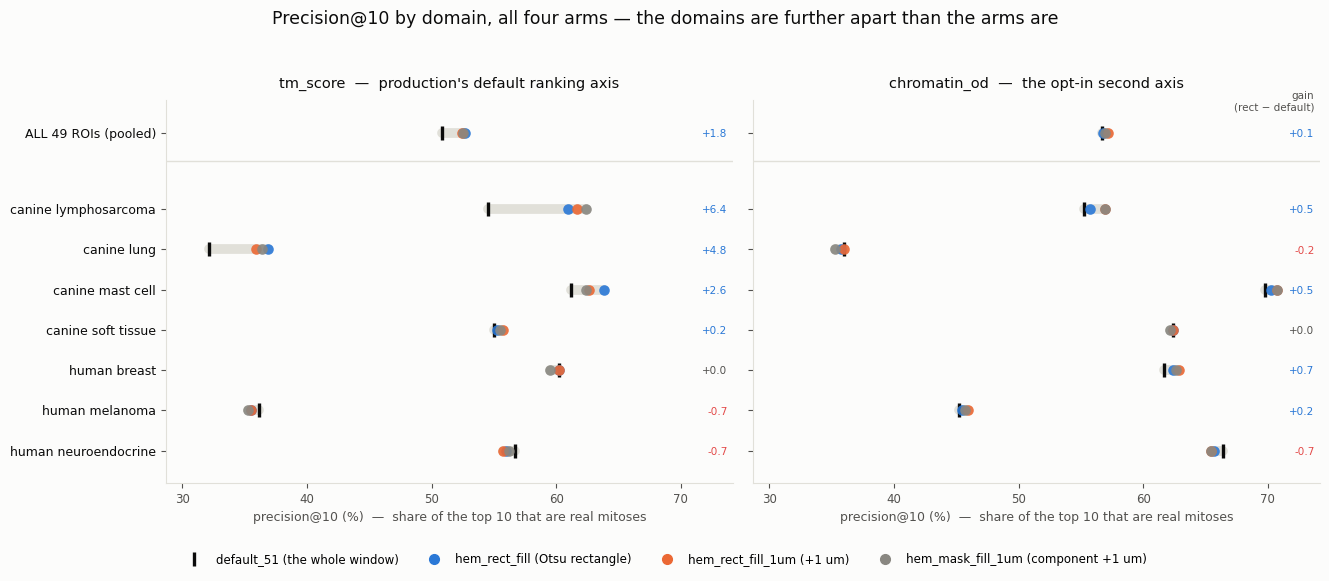

-> fillgeom6_domain_levels.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.4), sharey=True, sharex=True, facecolor=SURFACE)

for col, axis in enumerate(AXES):
    ax = axes[col]
    recessive(ax)
    ax.axhline(DIVIDER, color=GRID, linewidth=1, zorder=1)
    tab = PREC[PREC['rank_key'] == axis].pivot(index='domain', columns='condition', values='precision') * 100

    for dom in ORDER + [POOLED_LABEL]:
        y, row = YPOS[dom], tab.loc[dom]
        lo, hi = row[list(ARMS)].min(), row[list(ARMS)].max()
        ax.plot([lo, hi], [y, y], color=GRID, linewidth=7, solid_capstyle='round', zorder=2)
        gain = row['hem_rect_fill'] - row[BASELINE]
        ax.annotate(f'{gain:+.1f}', (1.0, y), xycoords=('axes fraction', 'data'), xytext=(-4, -3), textcoords='offset points',
                    ha='right', fontsize=7.5, color=BLUE if gain > 0 else RED if gain < 0 else MUTED)
        for arm in ARMS:
            is_base = arm == BASELINE
            ax.scatter([row[arm]], [y], s=92 if is_base else 58, marker='|' if is_base else 'o', color=ARM_COLOR[arm],
                       linewidths=2.4 if is_base else 0, alpha=1.0 if is_base else 0.9, zorder=4)

    ax.set_title(AXIS_NOTE[axis], fontsize=10.5, color=INK, pad=9)
    ax.set_xlabel(f'precision@{TEST_K} (%)  —  share of the top {TEST_K} that are real mitoses', fontsize=9, color=MUTED)

axes[0].set_yticks(YTICKS)
axes[0].set_yticklabels(YLABELS, fontsize=9, color=INK)
axes[0].set_ylim(-0.8, YPOS[POOLED_LABEL] + 0.8)
axes[0].margins(x=0.09)
axes[1].annotate('gain\n(rect − default)', (1.0, YPOS[POOLED_LABEL] + 0.55), xycoords=('axes fraction', 'data'), xytext=(-4, 0),
                 textcoords='offset points', ha='right', fontsize=7.5, color=MUTED)

handles = [mlines.Line2D([], [], color=ARM_COLOR[BASELINE], marker='|', linestyle='none', markersize=10, markeredgewidth=2.4, label=ARM_LABEL[BASELINE])]
handles += [mlines.Line2D([], [], color=ARM_COLOR[a], marker='o', linestyle='none', markersize=7, label=ARM_LABEL[a]) for a in ARMS[1:]]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=8.5, frameon=False, bbox_to_anchor=(0.5, -0.06))
fig.suptitle(f'Precision@{TEST_K} by domain, all four arms — the domains are further apart than the arms are', fontsize=12.5, color=INK, y=0.99)
fig.tight_layout(rect=[0, 0.01, 1, 0.955])
fig.savefig(FIG['levels'], dpi=150, bbox_inches='tight', facecolor=SURFACE)
plt.show()
print(f"-> {FIG['levels']}")

## Figure 3 -- how much a single domain number is worth

Both panels are `tm_score`, the axis that carries a claim; there is no effect on `chromatin_od` whose
fragility would be worth drawing, and its rows are in the CSV.

**Left: the same domain read three ways.** At 3 clicks per ROI (the click count every earlier run used),
at 6, and at 6 with that domain's largest-magnitude ROI deleted. A domain whose three readings sit apart
is a number that a small change in how you look produces, not a property of the tissue.

**Right: how far each domain is from being resolvable at all.** The hollow marker is the *smallest
Holm-adjusted p that domain could ever produce* -- `2 ** (1 - n_nonzero)` times 7 domains -- and the filled
marker is what it did produce. Everything to the right of the dashed line cannot be called significant.
The hollow markers are all on that side, which is Cell 2's arithmetic drawn out: no amount of effect would
move them.

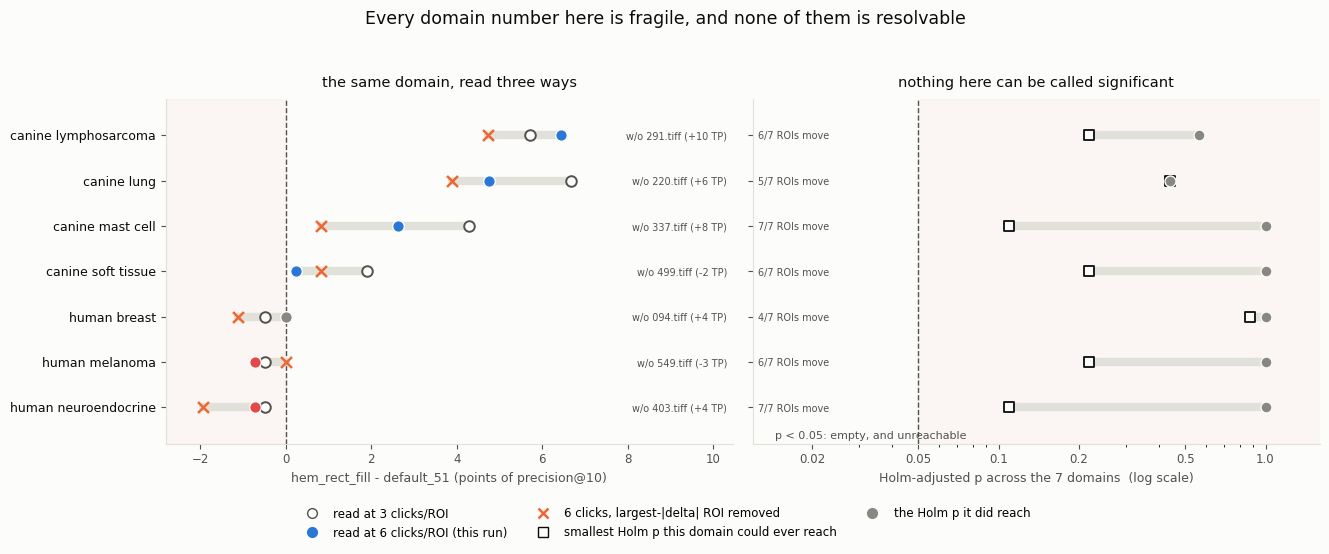

-> fillgeom6_domain_fragility.png

reading the same domain at 3 clicks instead of 6 moves it by up to 1.90 points (canine lung: +6.67 -> +4.76); no domain changes sign, and 1 lands on exactly 0
removing one ROI costs up to 1.79 points (canine mast cell: +2.62 -> +0.83 without 337.tiff, which is 73% of that domain's whole sum)
worst Holm-adjusted p any domain could have reached: 0.1094 -- every domain's floor is above 0.05


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.0), sharey=True, facecolor=SURFACE)
left, right = axes
stats = DOMAIN_STATS[(DOMAIN_STATS['rank_key'] == 'tm_score') & (DOMAIN_STATS['pair'] == HEADLINE) & (DOMAIN_STATS['scope'] == 'domain')].set_index('domain')

recessive(left)
left.axvspan(-1e3, 0, color=RED, alpha=0.035, zorder=0)
left.axvline(0, color=MUTED, linewidth=1, linestyle='--', zorder=1)
for dom in ORDER:
    row, y = stats.loc[dom], YPOS[dom]
    three, six, loo = 100 * row['delta_3click'], 100 * row['pooled_delta_precision'], 100 * row['loo_delta']
    left.plot([min(three, six, loo), max(three, six, loo)], [y, y], color=GRID, linewidth=6, solid_capstyle='round', zorder=2)
    left.scatter([three], [y], s=58, facecolors=SURFACE, edgecolors=MUTED, linewidths=1.4, zorder=4)
    left.scatter([loo], [y], s=62, marker='x', color=ORANGE, linewidths=1.8, zorder=4)
    left.scatter([six], [y], s=70, color=BLUE if six > 0 else RED if six < 0 else GRAY, edgecolors=SURFACE, linewidths=1.0, zorder=5)
    left.annotate(f"w/o {row['loo_file']} ({int(row['loo_delta_tp']):+d} TP)", (1.0, y), xycoords=('axes fraction', 'data'),
                  xytext=(-4, -3), textcoords='offset points', ha='right', fontsize=7, color=MUTED)
left.set_xlabel(f'{HEADLINE} (points of precision@{TEST_K})', fontsize=9, color=MUTED)
left.set_title('the same domain, read three ways', fontsize=10.5, color=INK, pad=9)
reads = 100 * np.concatenate([stats['delta_3click'], stats['pooled_delta_precision'], stats['loo_delta']])
left.set_xlim(reads.min() - 0.10 * reads.ptp(), reads.max() + 0.44 * reads.ptp())   # right headroom for the removed-ROI column

recessive(right)
right.set_xscale('log')
right.axvspan(0.05, 2.0, color=RED, alpha=0.035, zorder=0)
right.axvline(0.05, color=MUTED, linewidth=1, linestyle='--', zorder=1)
for dom in ORDER:
    row, y = stats.loc[dom], YPOS[dom]
    floor, got = row['holm_adjusted_floor'], min(row['holm_p'], 1.0)
    right.plot([floor, got], [y, y], color=GRID, linewidth=6, solid_capstyle='round', zorder=2)
    right.scatter([floor], [y], s=62, marker='s', facecolors=SURFACE, edgecolors=INK, linewidths=1.3, zorder=4)
    right.scatter([got], [y], s=62, color=GRAY, edgecolors=SURFACE, linewidths=1.0, zorder=5)
    right.annotate(f"{int(row['n_nonzero'])}/7 ROIs move", (0.0, y), xycoords=('axes fraction', 'data'),
                   xytext=(4, -3), textcoords='offset points', ha='left', fontsize=7, color=MUTED)
right.set_xlim(0.012, 1.6)                                     # the p < 0.05 side is kept in frame precisely to show it empty
right.set_xticks([0.02, 0.05, 0.1, 0.2, 0.5, 1.0])
right.set_xticklabels(['0.02', '0.05', '0.1', '0.2', '0.5', '1.0'])
right.annotate('p < 0.05: empty, and unreachable', (0.0145, -0.62), ha='left', va='center', fontsize=8, color=MUTED)
right.set_xlabel('Holm-adjusted p across the 7 domains  (log scale)', fontsize=9, color=MUTED)
right.set_title('nothing here can be called significant', fontsize=10.5, color=INK, pad=9)

left.set_yticks([YPOS[d] for d in ORDER])
left.set_yticklabels([SHORT[d] for d in ORDER], fontsize=9, color=INK)
left.set_ylim(-0.8, len(ORDER) - 0.2)

handles = [mlines.Line2D([], [], markerfacecolor=SURFACE, markeredgecolor=MUTED, marker='o', linestyle='none', markersize=7, label='read at 3 clicks/ROI'),
           mlines.Line2D([], [], color=BLUE, marker='o', linestyle='none', markersize=7, label='read at 6 clicks/ROI (this run)'),
           mlines.Line2D([], [], color=ORANGE, marker='x', linestyle='none', markersize=7, markeredgewidth=1.8, label="6 clicks, largest-|delta| ROI removed"),
           mlines.Line2D([], [], markerfacecolor=SURFACE, markeredgecolor=INK, marker='s', linestyle='none', markersize=7, label='smallest Holm p this domain could ever reach'),
           mlines.Line2D([], [], color=GRAY, marker='o', linestyle='none', markersize=7, label='the Holm p it did reach')]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=8.5, frameon=False, bbox_to_anchor=(0.5, -0.09))
fig.suptitle('Every domain number here is fragile, and none of them is resolvable', fontsize=12.5, color=INK, y=0.99)
fig.tight_layout(rect=[0, 0.01, 1, 0.955])
fig.savefig(FIG['fragility'], dpi=150, bbox_inches='tight', facecolor=SURFACE)
plt.show()
print(f"-> {FIG['fragility']}")

move = (100 * (stats['delta_3click'] - stats['pooled_delta_precision'])).abs()
drop = 100 * (stats['pooled_delta_precision'] - stats['loo_delta'])
print(f"\nreading the same domain at 3 clicks instead of 6 moves it by up to {move.max():.2f} points ({SHORT[move.idxmax()]}: "
      f"{100 * stats.loc[move.idxmax(), 'delta_3click']:+.2f} -> {100 * stats.loc[move.idxmax(), 'pooled_delta_precision']:+.2f}); "
      f"no domain changes sign, and {int(((stats['delta_3click'] != 0) & (stats['pooled_delta_precision'] == 0)).sum())} lands on exactly 0")
print(f"removing one ROI costs up to {drop.max():.2f} points ({SHORT[drop.idxmax()]}: {100 * stats.loc[drop.idxmax(), 'pooled_delta_precision']:+.2f} -> "
      f"{100 * stats.loc[drop.idxmax(), 'loo_delta']:+.2f} without {stats.loc[drop.idxmax(), 'loo_file']}, which is "
      f"{stats.loc[drop.idxmax(), 'loo_delta_tp'] / (stats.loc[drop.idxmax(), 'pooled_delta_precision'] * N_CLICKS * N_PER_DOMAIN * TEST_K):.0%} of that domain's whole sum)")
print(f"worst Holm-adjusted p any domain could have reached: {stats['holm_adjusted_floor'].min():.4f} -- every domain's floor is above 0.05")

## Figure 4 -- the pattern the domains make, and what it is probably made of

Figure 1's ordering is not random: the four canine domains sit at or above zero and the three human ones
at or below it. Before reading that as a species effect, notice what else is ordered the same way. Each
arm's intervention is *overwriting the part of the 51 px window outside the nucleus*, so **how much of the
window it actually overwrites is the dose**, and that dose depends on how big the nucleus is relative to
the window. Human nuclei in this sample are larger -- the cell below prints the per-species median Otsu
rectangle -- which leaves less surround to flatten.

So there are two readings of the same ordering, and **this sample cannot separate them**: 22 of 28 canine
ROIs fall below the median rectangle size and 18 of 21 human ROIs above it. Species and dose are very
nearly the same variable here.

They are not equally good hypotheses, though. "Canine mitoses respond to template flattening" proposes no
mechanism. "Flattening does more when there is more to flatten" is a restatement of what the arms do, and
it makes a **falsifiable prediction**: the gradient should exist on `tm_score`, where the template drives
the ranking, and be absent on `chromatin_od`, where the ranking is a statistic the template does not
touch. The right-hand panel is that test.

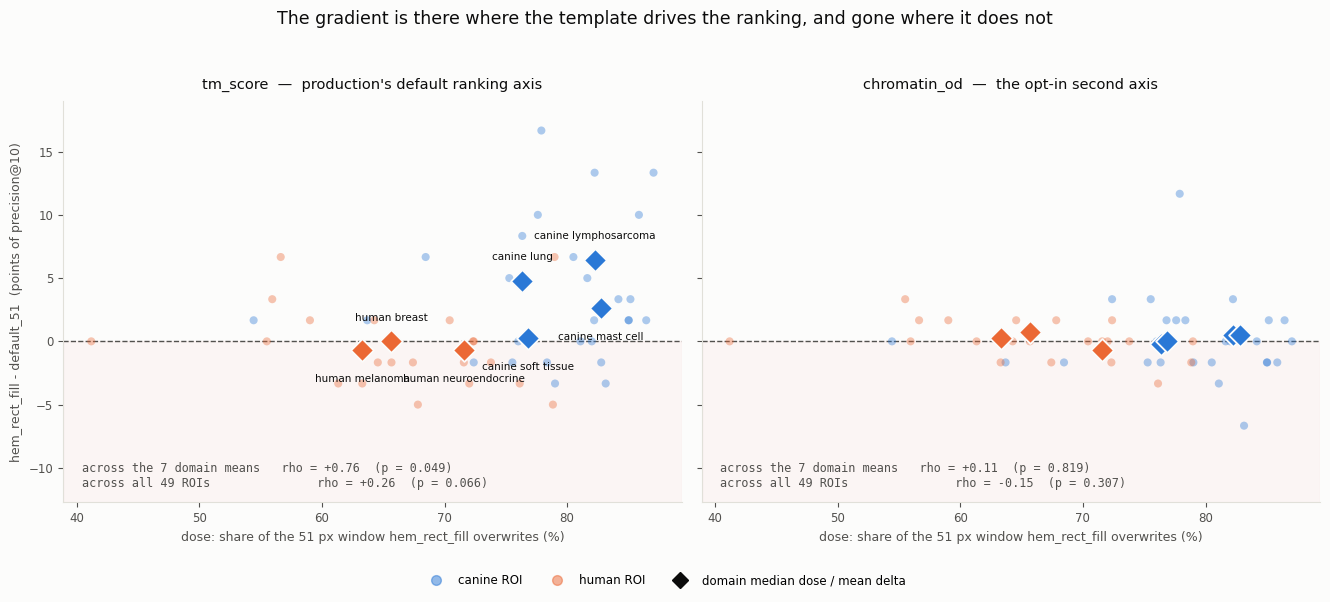

-> fillgeom6_domain_dose.png
tm_score      high-dose half (n = 24) +3.54 pts | low-dose half (n = 25) +0.13 pts | rho +0.76 (p 0.049) across the 7 domain means, +0.26 (p 0.066) across all 49 ROIs
chromatin_od  high-dose half (n = 24) -0.07 pts | low-dose half (n = 25) +0.33 pts | rho +0.11 (p 0.819) across the 7 domain means, -0.15 (p 0.307) across all 49 ROIs


In [8]:
# dose = the share of the 51 x 51 window hem_rect_fill actually overwrites, per ROI (median over its 6 clicks)
DOSE = CLICKS.groupby('file_name', sort=False).agg(domain=('domain', 'first'), filled_px=('n_filled_px', 'median'), rect_px=('n_kept_px_rect', 'median')).reset_index()
DOSE['dose'] = DOSE['filled_px'] / WINDOW_PX
DOSE['species'] = np.where(DOSE['domain'].str.startswith('canine'), 'canine', 'human')
SPECIES_COLOR = {'canine': BLUE, 'human': ORANGE}

fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.6), sharey=True, sharex=True, facecolor=SURFACE)
rho_note = {}
for col, axis in enumerate(AXES):
    ax = axes[col]
    recessive(ax)
    ax.axhspan(-1e3, 0, color=RED, alpha=0.035, zorder=0)
    ax.axhline(0, color=MUTED, linewidth=1, linestyle='--', zorder=1)
    m = DELTA[(DELTA['rank_key'] == axis) & (DELTA['pair'] == HEADLINE)][['file_name', 'domain', 'delta_tp_sum']].merge(DOSE.drop(columns='domain'), on='file_name')
    m['delta_pts'] = m['delta_tp_sum'] * PTS

    for sp, g in m.groupby('species'):
        ax.scatter(100 * g['dose'], g['delta_pts'], s=34, color=SPECIES_COLOR[sp], alpha=0.38, edgecolors='none', zorder=3)
    means = m.groupby('domain').agg(dose=('dose', 'median'), delta_pts=('delta_pts', 'mean'), species=('species', 'first')).loc[ORDER]
    by_dose = means.sort_values('dose')
    for i, (dom, row) in enumerate(by_dose.iterrows()):
        ax.scatter([100 * row['dose']], [row['delta_pts']], s=135, marker='D', color=SPECIES_COLOR[row['species']], edgecolors=SURFACE, linewidths=1.3, zorder=5)
        if col > 0:                                  # the x positions are identical in both panels, so one set of labels serves both
            continue
        neighbours = by_dose['delta_pts'].to_numpy()[[j for j in (i - 1, i + 1) if 0 <= j < len(by_dose)]]
        above = row['delta_pts'] >= neighbours.mean()   # label away from the nearest domains in dose, so x-adjacent labels never stack
        ax.annotate(SHORT[dom], (100 * row['dose'], row['delta_pts']), xytext=(0, 15 if above else -23), textcoords='offset points', ha='center', fontsize=7.5, color=INK)

    rho_roi, p_roi = sps.spearmanr(m['dose'], m['delta_tp_sum'])
    rho_dom, p_dom = sps.spearmanr(means['dose'], means['delta_pts'])
    rho_note[axis] = (rho_roi, p_roi, rho_dom, p_dom)
    ax.annotate(f'across the 7 domain means   rho = {rho_dom:+.2f}  (p = {p_dom:.3f})\nacross all 49 ROIs               rho = {rho_roi:+.2f}  (p = {p_roi:.3f})',
                (0.03, 0.03), xycoords='axes fraction', fontsize=8.5, color=MUTED, family='DejaVu Sans Mono', va='bottom')
    ax.set_title(AXIS_NOTE[axis], fontsize=10.5, color=INK, pad=9)
    ax.set_xlabel('dose: share of the 51 px window hem_rect_fill overwrites (%)', fontsize=9, color=MUTED)

# axhspan spans the whole real line, so the y limits are set from the data after both panels are drawn
all_pts = DELTA[DELTA['pair'] == HEADLINE]['delta_tp_sum'].to_numpy() * PTS
axes[0].set_ylim(all_pts.min() - 0.26 * all_pts.ptp(), all_pts.max() + 0.10 * all_pts.ptp())   # bottom headroom for the rho block
axes[0].set_ylabel(f'{HEADLINE}  (points of precision@{TEST_K})', fontsize=9, color=MUTED)
handles = [mlines.Line2D([], [], color=SPECIES_COLOR[s], marker='o', linestyle='none', markersize=7, alpha=0.5, label=f'{s} ROI') for s in ('canine', 'human')]
handles += [mlines.Line2D([], [], color=INK, marker='D', linestyle='none', markersize=8, label='domain median dose / mean delta')]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=8.5, frameon=False, bbox_to_anchor=(0.5, -0.06))
fig.suptitle('The gradient is there where the template drives the ranking, and gone where it does not', fontsize=12.5, color=INK, y=0.99)
fig.tight_layout(rect=[0, 0.01, 1, 0.955])
fig.savefig(FIG['dose'], dpi=150, bbox_inches='tight', facecolor=SURFACE)
plt.show()
print(f"-> {FIG['dose']}")

for axis in AXES:
    m = DELTA[(DELTA['rank_key'] == axis) & (DELTA['pair'] == HEADLINE)][['file_name', 'delta_tp_sum']].merge(DOSE[['file_name', 'dose']], on='file_name')
    half = m['dose'] > m['dose'].median()
    parts = [f"{'high' if h else 'low'}-dose half (n = {len(g)}) {100 * g['delta_tp_sum'].sum() / (N_CLICKS * len(g) * TEST_K):+.2f} pts" for h, g in m.groupby(half)][::-1]
    rho_roi, p_roi, rho_dom, p_dom = rho_note[axis]
    print(f'{axis:13s} ' + ' | '.join(parts) + f' | rho {rho_dom:+.2f} (p {p_dom:.3f}) across the 7 domain means, {rho_roi:+.2f} (p {p_roi:.3f}) across all 49 ROIs')

In [9]:
# The species split, quantified -- and every reason it is weaker than its p-value looks.
print('POST-HOC. This contrast was chosen after seeing Figure 1, is in no Holm family, and is not a result of the parent run.\n')

split = DELTA[(DELTA['rank_key'] == 'tm_score') & (DELTA['pair'] == HEADLINE)].set_index('file_name').loc[ROI_ORDER]
split = split.assign(species=np.where(split['domain'].str.startswith('canine'), 'canine', 'human'))
rows = []
for sp, g in split.groupby('species'):
    boot = np.random.default_rng([BOOT_SEED, 2, len(g)]).integers(len(g), size=(N_BOOT, len(g)))
    st = pair_stats(g['delta_tp_sum'].to_numpy(), boot)
    rows.append(dict(group=sp, n_roi=st['n_roi'], delta_pts=round(100 * st['pooled_delta_precision'], 2),
                     boot_ci95=f"[{100 * st['ci_low']:+.2f}, {100 * st['ci_high']:+.2f}]",
                     wlt=f"{st['wins']}/{st['losses']}/{st['ties']}", n_nonzero=st['n_nonzero'], exact_p=round(st['exact_p'], 4)))
print(pd.DataFrame(rows).to_string(index=False))
print('in raw counts: ' + ', '.join(f"{sp} {int(g['delta_tp_sum'].sum()):+d} TP over {len(g)} ROIs" for sp, g in split.groupby('species')))

print('\nthe same split on the other two primary arms, and on the other axis:')
for axis in AXES:
    for pair in PRIMARY:
        s = DELTA[(DELTA['rank_key'] == axis) & (DELTA['pair'] == pair)]
        s = s.assign(species=np.where(s['domain'].str.startswith('canine'), 'canine', 'human'))
        parts = [f"{sp} {100 * g['delta_tp_sum'].sum() / (N_CLICKS * len(g) * TEST_K):+.2f} pts (p {exact_sign_flip_p(g['delta_tp_sum'].to_numpy())[0]:.4f})" for sp, g in s.groupby('species')]
        print(f'  {axis:13s} {pair:34s} ' + ' | '.join(parts))
print('  NOT three confirmations: the three arms are near-identical interventions scored on the same 294 clicks,')
print('  so they agree by construction. It rules out an arm-specific artefact and nothing more.')

canine = split[split['species'] == 'canine']
drop = canine['delta_tp_sum'].abs().idxmax()
rest = canine.drop(index=drop)
print(f"\nthe canine block is not uniform either: dropping its largest ROI ({drop}, {int(canine.loc[drop, 'delta_tp_sum']):+d} TP) leaves "
      f"{100 * rest['delta_tp_sum'].sum() / (N_CLICKS * len(rest) * TEST_K):+.2f} pts over {len(rest)} ROIs, and its weakest domain "
      f"(canine soft tissue sarcoma, {100 * DOMAIN_STATS.loc[(DOMAIN_STATS['rank_key'] == 'tm_score') & (DOMAIN_STATS['pair'] == HEADLINE) & (DOMAIN_STATS['domain'] == 'canine soft tissue sarcoma'), 'pooled_delta_precision'].iat[0]:+.2f} pts) is flat.")

med = DOSE['rect_px'].median()
tab = pd.crosstab(DOSE['species'], pd.Series(np.where(DOSE['rect_px'] > med, 'nucleus above median', 'nucleus below median'), name=''))
print(f"\nspecies and nucleus size are the same variable in this sample (median Otsu rectangle over all 49 ROIs: {med:.0f} px;")
print('by species: ' + ', '.join(f'{sp} {g["rect_px"].median():.0f} px' for sp, g in DOSE.groupby('species')) + '):')
print(tab.to_string())
print('\nsplits that were NOT run, and would each have been as available as this one: subset (original_14 vs testing_35),')
print('scanner, baseline precision above/below median, nucleus size above/below median, contested vs unanimous annotation tier.')
print(f"a 49-ROI sample supports one such split at a time; this one is reported because a mechanism predicts it and that")
print(f"prediction is testable on the second axis (Figure 4, right panel: rho {rho_note['chromatin_od'][2]:+.2f}, p {rho_note['chromatin_od'][3]:.3f} -- no gradient).")

POST-HOC. This contrast was chosen after seeing Figure 1, is in no Holm family, and is not a result of the parent run.

 group  n_roi  delta_pts      boot_ci95    wlt  n_nonzero  exact_p
canine     28       3.51 [+1.67, +5.60] 18/6/4         24   0.0014
 human     21      -0.48 [-1.83, +0.95] 6/11/4         17   0.5820
in raw counts: canine +59 TP over 28 ROIs, human -6 TP over 21 ROIs

the same split on the other two primary arms, and on the other axis:
  tm_score      hem_rect_fill - default_51         canine +3.51 pts (p 0.0014) | human -0.48 pts (p 0.5820)
  tm_score      hem_rect_fill_1um - default_51     canine +3.27 pts (p 0.0011) | human -0.56 pts (p 0.4482)
  tm_score      hem_mask_fill_1um - default_51     canine +3.45 pts (p 0.0023) | human -0.71 pts (p 0.4636)
  chromatin_od  hem_rect_fill - default_51         canine +0.18 pts (p 0.8561) | human +0.08 pts (p 1.0000)
  chromatin_od  hem_rect_fill_1um - default_51     canine +0.65 pts (p 0.3606) | human +0.32 pts (p 0.6113)
 

## Reading the result

Every number below is printed by a cell above. "Points" are percentage points of precision@10, the parent
run's only tested budget. Every delta is `hem_rect_fill - default_51` unless named otherwise.

### The pooled +1.80 points is not spread over the 49 ROIs -- it is concentrated in three domains

At `tm_score`, the domain deltas span **7.14 points end to end**, from `canine lymphosarcoma` **+6.43** down
to `human melanoma` and `human neuroendocrine tumor` at **-0.71**. Three domains carry essentially all of
it -- lymphosarcoma (+6.43), `canine lung cancer` (+4.76), `canine cutaneous mast cell tumor` (+2.62) --
while `canine soft tissue sarcoma` (+0.24) and `human breast cancer` (0.00) are flat and the other two
human domains are slightly negative. The four canine domains sum to **+59 TP** and the three human domains
to **-6 TP**.

At `chromatin_od` every domain is inside +/-0.71 points. The pooled null on that axis is a null everywhere,
not an average of offsetting domains.

### No domain result is established, and none can be

This is not a hedge, it is Cell 2's arithmetic: with 7 ROIs a domain's exact sign-flip p cannot go below
0.0156, and across 7 domains the Holm-adjusted floor is **0.109**. Every domain's *best possible* p sits on
the wrong side of 0.05 (Figure 3, right). `canine lung cancer`'s 5W/0L/2T and exact p of **0.0625 is
exactly its floor** -- every ROI that moved, moved the same way, the most extreme outcome n = 5 permits --
and it is still not significant. Read it as "nothing in this domain contradicted the effect", never as
"lung cancer was significant".

Figure 3's left panel says the same thing a second way. Read at 3 clicks per ROI instead of 6, the domain
estimates move by up to **1.90 points** (`canine lung cancer`, +6.67 -> +4.76) and `human breast cancer` lands
on exactly 0; and `canine cutaneous mast cell tumor`'s +2.62 falls to **+0.83** when its single largest ROI
(`337.tiff`, +8 TP, 73% of the domain's whole sum) is removed.

### The domains are much further apart than the arms are

Figure 2 is the one to keep for product decisions. Baseline precision@10 at `tm_score` runs from **32.14%**
(`canine lung cancer`) to **61.19%** (`canine cutaneous mast cell tumor`) -- a 29.05-point spread across
tissue types, against the 1.80-point spread the whole surround-fill question is about. The three fill arms
sit within **1.43 points** of each other in every single domain, on both axes. Whatever is worth doing next for a domain like
canine lung cancer, it is not template geometry.

### What the domain ordering is probably made of

The ordering tracks **dose** -- how much of the 51 px window each template actually overwrites. At
`tm_score` the high-dose half of the ROIs gains **+3.54 points** against **+0.13** for the low-dose half.
The rank correlation is **+0.76 across the 7 domain means (p = 0.049)** but only **+0.26 across all 49 ROIs
(p = 0.066)** -- and the first of those is itself a 7-point correlation one point away from nothing, the
same small-n arithmetic this notebook spends its middle section warning about. The gradient is between
domains; individual ROIs scatter through it.

The prediction that distinguishes this from a species story is on the second axis: the template drives the
ranking at `tm_score` but not at `chromatin_od`, so a dose effect must vanish there. It does -- **+0.11
across domain means, p = 0.819**, with the high-dose half at **-0.07 points** against **+0.33** for the low. A species explanation
predicts nothing about which axis the pattern appears on.

That is evidence for the mechanism, not proof of it, and **the confound is not resolved**: 22 of 28 canine
ROIs have below-median nuclei and 18 of 21 human ROIs above-median, so in this sample "canine" and "small
nucleus relative to the window" are nearly the same label. Separating them needs ROIs that break the
pairing -- large-nucleus canine, small-nucleus human -- which this 49-ROI population does not contain.

The post-hoc canine/human contrast itself is **+3.51 points [+1.67, +5.60], 18W/6L/4T, exact p 0.0014**
against **-0.48 [-1.83, +0.95], p 0.582** for human. It is in no Holm family, it was chosen after seeing
Figure 1, and at least five other splits were equally available and were not run. Dropping the canine
block's largest ROI (`291.tiff`, +10 TP) leaves **+3.02 points over 27 ROIs**, and one of its four domains is flat.

### What to carry forward

1. **The pooled result stands as the parent notebook stated it.** Nothing here revises +1.80 points, its
   CI, or its Holm p. A decomposition cannot overturn what it decomposes.
2. **Do not quote a per-domain number as a finding.** No domain is resolvable at n = 7, two of the
   positive ones are one-ROI-deep, and this project has already watched its most promising domain signal
   shrink toward zero when n was tripled.
3. **The dose reading is the better-supported of two confounded explanations, not an established
   gradient.** What it has going for it is that it is mechanistic and that it made a prediction which could
   have failed and did not: no dose gradient on the axis where the template does not rank. What it does not
   have is strength at the unit a run would be designed around -- **rho +0.26, p = 0.066 across the 49
   ROIs**. Its value is that it converts a question about tissue type, which needs many more ROIs per
   domain, into a question about nucleus size relative to the template window, which is already measured on
   every click in hand. That makes it the stratification variable worth *carrying*, not yet a result worth
   building a run around.

### Standing caveats

- Inherited whole from the parent run: 294 joint-gated clicks, one channel, one margin, `max_peaks`
  binding on all 2352 rows, K = 10 only, and two ranking axes that rank the same detections.
- 7 ROIs per domain, fixed by the parent run's population. This notebook drew no new clicks and ran no
  new search; it cannot add resolution, only show how little there is.
- The bootstrap CIs on domains resample 7 clusters. At that n a percentile bootstrap is not a reliable
  interval; it is drawn as a spread and read as one.